# 03 — Retrieval Effects on Generation Across Popularity

One compact figure: all base strategies over popularity deciles.

Columns show:
- generation accuracy
- retrieval hit rate
- conditional generation-accuracy difference between retrieval hits and misses

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.full_pipe_eval.shared_setup import *

EVALUATOR = AVAILABLE_EVALUATORS[0] if AVAILABLE_EVALUATORS else None
MODE = DECILE_MODE
print(f'Evaluator: {EVALUATOR}')
print(f'Decile mode: {MODE}')
print(f'LLMs: {AVAILABLE_LLMS}')
print(f'Backends: {AVAILABLE_BACKENDS}')
print(f'Contexts: {AVAILABLE_CONTEXTS}')

Loading full-pipeline results from: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
  ✓ neo | zero_shot | substring: 7,383 rows
  ✓ neo | bm25_plus top3 | substring: 7,383 rows
  ✓ neo | ivfpq_high top3 | substring: 7,383 rows
  ✓ qwen | zero_shot | substring: 7,383 rows
  ✓ qwen | bm25_plus top3 | substring: 7,383 rows
  ✓ qwen | ivfpq_high top3 | substring: 7,383 rows

✓ shared_setup complete — 6 runs, 44,298 rows
  llms      : ['neo', 'qwen']
  backends  : ['bm25_plus', 'ivfpq_high', 'zero_shot']
  contexts  : ['top3', 'zero']
  evaluators: ['substring']
Evaluator: substring
Decile mode: chunk_weighted
LLMs: ['neo', 'qwen']
Backends: ['bm25_plus', 'ivfpq_high', 'zero_shot']
Contexts: ['top3', 'zero']


## Compact Popularity-Decile View

Each row is one LLM. Each line is a backend/context strategy. This keeps the retrieval-to-generation relationship visible across popularity deciles without creating many separate plots.

,llm,backend,ctx_label,decile_label,generation_accuracy,retrieval_hit_rate,n,hit_lift
0,neo,bm25_plus,top3,1,0.3571,0.6204,490,0.1944
1,neo,bm25_plus,top3,2,0.3323,0.5228,635,0.0801
2,neo,bm25_plus,top3,3,0.3213,0.5120,750,0.2380
3,neo,bm25_plus,top3,4,0.3042,0.5019,779,0.2108
4,neo,bm25_plus,top3,5,0.3111,0.4981,781,0.2252
5,neo,bm25_plus,top3,6,0.3050,0.4865,777,0.2251
6,neo,bm25_plus,top3,7,0.3046,0.4632,788,0.2186
7,neo,bm25_plus,top3,8,0.3014,0.3884,793,0.2345
8,neo,bm25_plus,top3,9,0.3145,0.4013,795,0.1345
9,neo,bm25_plus,top3,10,0.2805,0.3107,795,0.0277


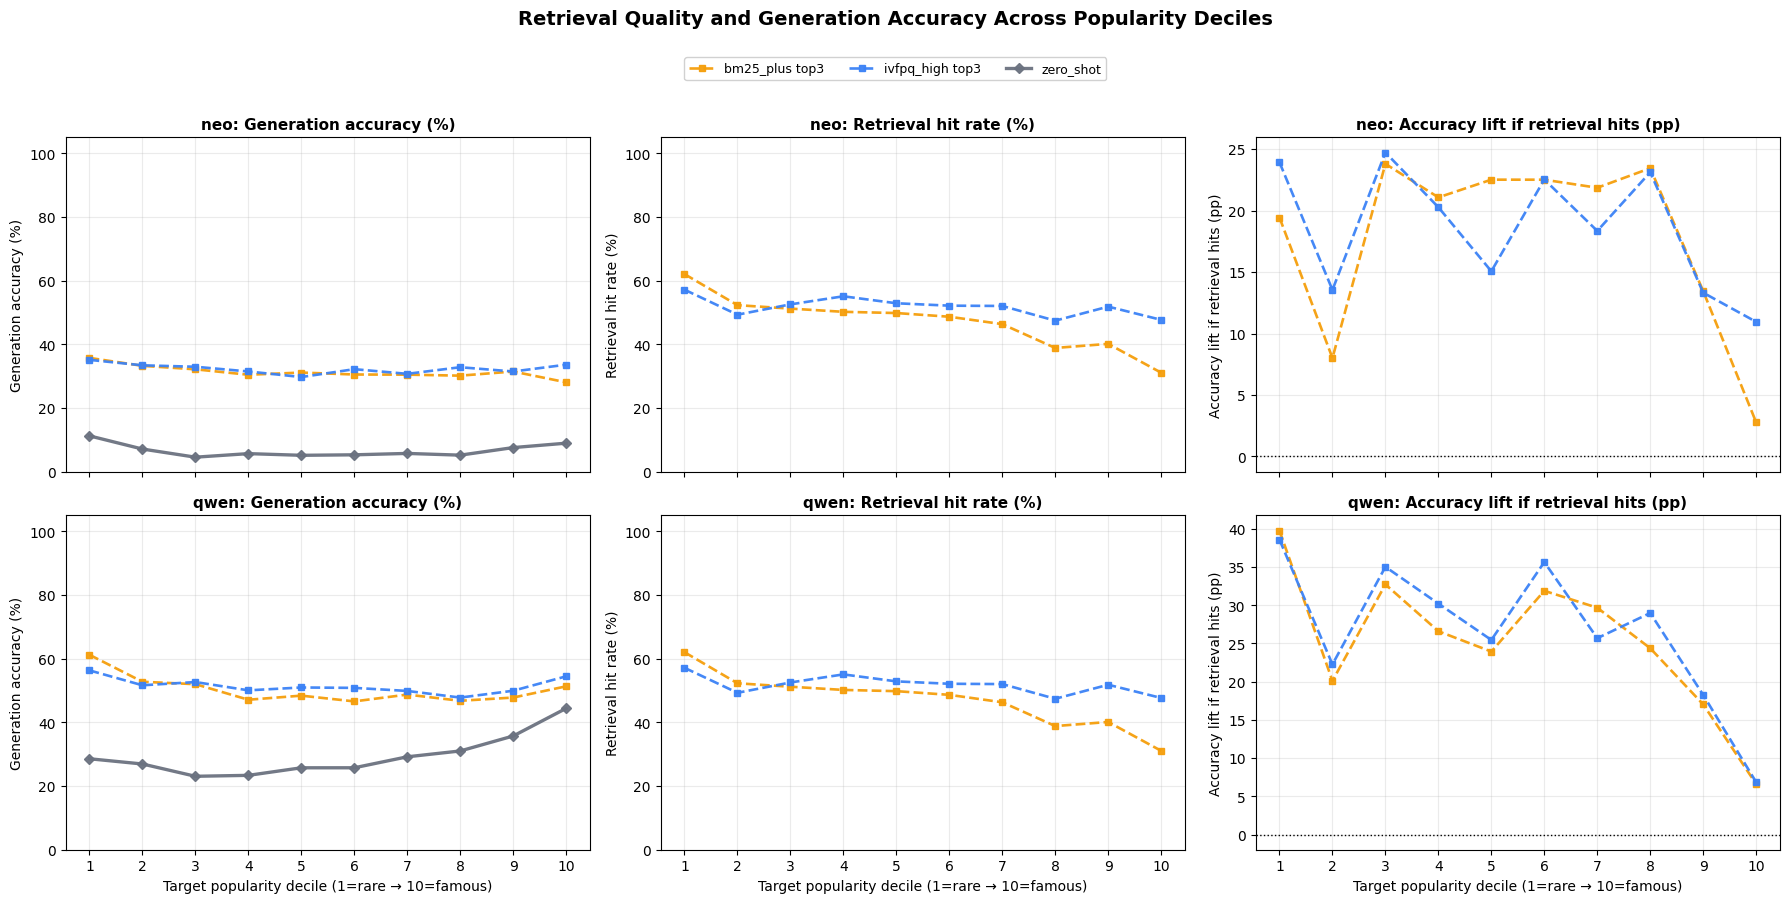

✓ Saved → compact_retrieval_generation_by_decile.png


In [2]:
dcol = decile_col_for_mode(MODE)
df = filter_generation_results(evaluator=EVALUATOR).copy()
df['decile'] = pd.to_numeric(df[dcol], errors='coerce').astype('Int64')
df = df.dropna(subset=['decile', 'generation_correct'])
df['decile_label'] = df['decile'].astype(int) + 1

summary = (
    df.groupby(['llm', 'backend', 'ctx_label', 'decile_label'])
    .agg(
        generation_accuracy=('generation_correct', 'mean'),
        retrieval_hit_rate=('retrieval_hit', 'mean'),
        n=('generation_correct', 'count'),
        retrieval_n=('retrieval_hit', 'count'),
    )
    .reset_index()
)
summary['generation_accuracy_ci95'] = 1.96 * np.sqrt(
    summary['generation_accuracy'] * (1.0 - summary['generation_accuracy']) / summary['n']
)
summary['retrieval_hit_rate_ci95'] = 1.96 * np.sqrt(
    summary['retrieval_hit_rate'] * (1.0 - summary['retrieval_hit_rate']) / summary['retrieval_n']
)

hit_miss = (
    df[df['retrieval_hit'].notna()]
    .groupby(['llm', 'backend', 'ctx_label', 'decile_label', 'retrieval_hit'])
    .agg(accuracy=('generation_correct', 'mean'), n=('generation_correct', 'count'))
    .reset_index()
)
lift = hit_miss.pivot_table(
    index=['llm', 'backend', 'ctx_label', 'decile_label'],
    columns='retrieval_hit',
    values='accuracy',
).reset_index()
lift = lift.rename(columns={0.0: 'acc_when_miss', 1.0: 'acc_when_hit'})
lift_counts = hit_miss.pivot_table(
    index=['llm', 'backend', 'ctx_label', 'decile_label'],
    columns='retrieval_hit',
    values='n',
).reset_index().rename(columns={0.0: 'n_when_miss', 1.0: 'n_when_hit'})
lift = lift.merge(lift_counts, on=['llm', 'backend', 'ctx_label', 'decile_label'], how='left')
lift['hit_lift'] = lift.get('acc_when_hit', np.nan) - lift.get('acc_when_miss', np.nan)
lift['hit_lift_ci95'] = 1.96 * np.sqrt(
    lift['acc_when_hit'] * (1.0 - lift['acc_when_hit']) / lift['n_when_hit']
    + lift['acc_when_miss'] * (1.0 - lift['acc_when_miss']) / lift['n_when_miss']
)
summary = summary.merge(lift[['llm', 'backend', 'ctx_label', 'decile_label', 'hit_lift', 'hit_lift_ci95']],
                        on=['llm', 'backend', 'ctx_label', 'decile_label'], how='left')
display(summary.round(4))

ctx_styles = {
    'zero': dict(linestyle='-', marker='D', linewidth=2.4),
    'top1': dict(linestyle='-', marker='o', linewidth=2.0),
    'top3': dict(linestyle='--', marker='s', linewidth=1.9),
}
default_style = dict(linestyle='-', marker='o', linewidth=1.8)
metrics = [
    ('generation_accuracy', 'Generation accuracy (%)'),
    ('retrieval_hit_rate', 'Retrieval hit rate (%)'),
    ('hit_lift', 'Conditional hit--miss accuracy difference (pp)'),
]
llms = AVAILABLE_LLMS or sorted(summary['llm'].dropna().unique())
fig, axes = plt.subplots(len(llms), len(metrics), figsize=(18, 4.2 * len(llms)), sharex=True)
if len(llms) == 1:
    axes = np.array([axes])

for row_idx, llm in enumerate(llms):
    sub_llm = summary[summary['llm'] == llm]
    for col_idx, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        for (backend, ctx), sub in sub_llm.groupby(['backend', 'ctx_label']):
            if metric in {'retrieval_hit_rate', 'hit_lift'} and backend == 'zero_shot':
                continue
            sub = sub.sort_values('decile_label')
            if sub[metric].notna().sum() == 0:
                continue
            style = ctx_styles.get(ctx, default_style)
            vals = sub[metric].to_numpy(dtype=float)
            if metric in {'generation_accuracy', 'retrieval_hit_rate'}:
                vals = vals * 100.0
            elif metric == 'hit_lift':
                vals = vals * 100.0
            label = backend if ctx == 'zero' else f'{backend} {ctx}'
            ci_col = f'{metric}_ci95'
            errs = sub[ci_col].to_numpy(dtype=float) * 100.0
            ax.errorbar(sub['decile_label'], vals, yerr=errs, color=backend_color(backend), label=label,
                        markersize=5, alpha=0.95, capsize=2, **style)
        ax.set_title(f'{llm}: {ylabel}', fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(1, 11))
        ax.grid(alpha=0.25)
        if metric in {'generation_accuracy', 'retrieval_hit_rate'}:
            ax.set_ylim(0, 105)
        if metric == 'hit_lift':
            ax.axhline(0, color='black', linewidth=1, linestyle=':')

for ax in axes[-1, :]:
    ax.set_xlabel('Target popularity decile (1=rare → 10=famous)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=min(4, max(1, len(labels))), fontsize=9, framealpha=0.9)
fig.suptitle('Retrieval Quality and Generation Accuracy Across Popularity Deciles',
             fontsize=14, fontweight='bold', y=1.07)
plt.tight_layout()
out = IMAGES_DIR / 'compact_retrieval_generation_by_decile.png'
plt.savefig(out, dpi=170, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## Qwen Decile Summary

Two paper-friendly plots for the main result: Qwen generation/retrieval accuracy by decile, and the conditional hit--miss accuracy difference. Vertical bars show 95% normal confidence intervals. Neo follows the same qualitative pattern and is summarized in the text.

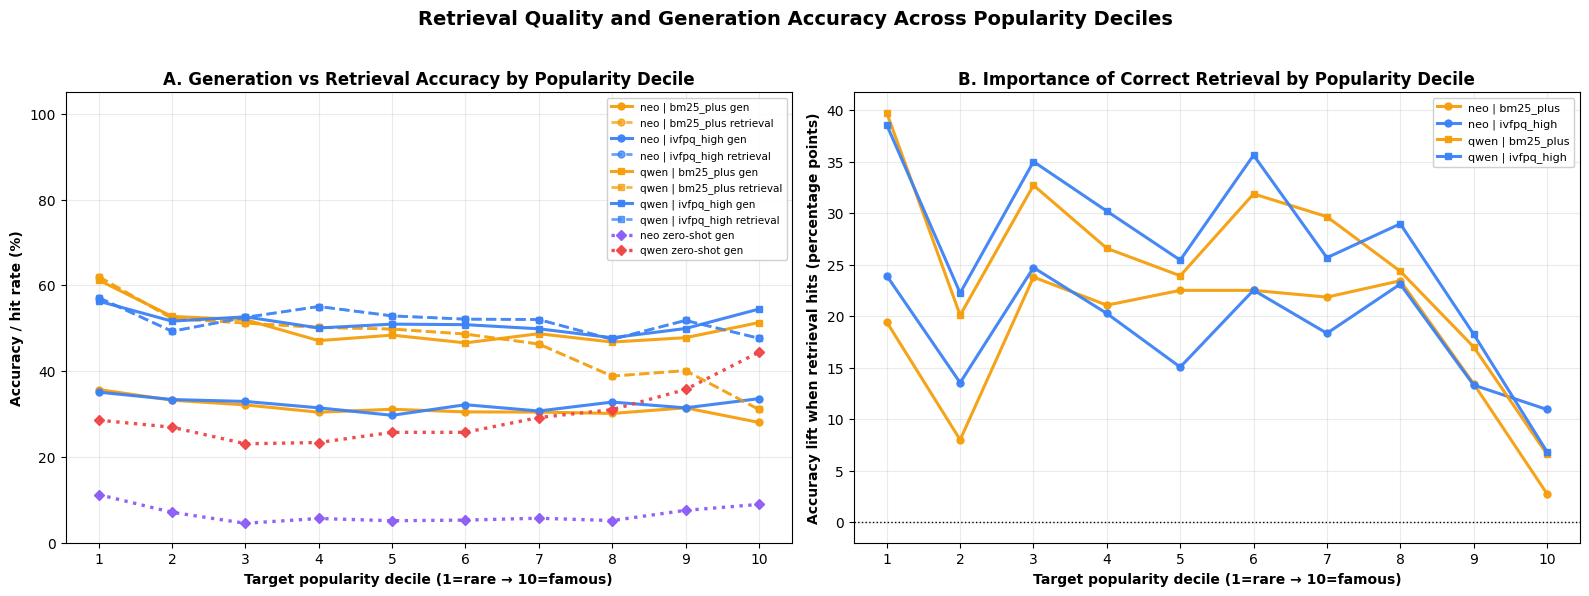

✓ Saved → generation_retrieval_accuracy_and_lift_by_decile.png


In [3]:
# Qwen-only paper figure: generation accuracy plus retrieval hit rate.
main_llm = 'qwen' if 'qwen' in set(summary['llm']) else summary['llm'].iloc[0]
qwen_summary = summary[summary['llm'] == main_llm].copy()
backend_labels = {'bm25_plus': 'BM25', 'ivfpq_high': 'FAISS high'}
retrieval_qwen = qwen_summary[qwen_summary['backend'] != 'zero_shot'].copy()
zero_qwen = qwen_summary[qwen_summary['backend'] == 'zero_shot'].copy()

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for backend, sub in retrieval_qwen.groupby('backend'):
    sub = sub.sort_values('decile_label')
    label = backend_labels.get(backend, backend)
    color = backend_color(backend)
    ax.errorbar(
        sub['decile_label'], sub['generation_accuracy'] * 100.0,
        yerr=sub['generation_accuracy_ci95'] * 100.0, capsize=3,
        color=color, marker='o', linestyle='-', linewidth=2.6, markersize=6,
        label=f'{label}: generation', alpha=0.95,
    )
    ax.errorbar(
        sub['decile_label'], sub['retrieval_hit_rate'] * 100.0,
        yerr=sub['retrieval_hit_rate_ci95'] * 100.0, capsize=3,
        color=color, marker='o', linestyle='--', linewidth=2.2, markersize=5,
        label=f'{label}: retrieval hit', alpha=0.78,
    )

if not zero_qwen.empty:
    zero_qwen = zero_qwen.sort_values('decile_label')
    ax.errorbar(
        zero_qwen['decile_label'], zero_qwen['generation_accuracy'] * 100.0,
        yerr=zero_qwen['generation_accuracy_ci95'] * 100.0, capsize=3,
        color='black', marker='D', linestyle=':', linewidth=2.6, markersize=5,
        label='Zero-shot: generation', alpha=0.9,
    )

ax.set_title('Qwen: Generation and Retrieval Accuracy by Popularity Decile', fontsize=13, fontweight='bold')
ax.set_xlabel('Target popularity decile (1=rare → 10=famous)', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy / retrieval hit rate (%)', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 105)
ax.grid(alpha=0.25)
ax.legend(fontsize=8.5, framealpha=0.92, loc='best')
plt.tight_layout()
out = IMAGES_DIR / 'qwen_generation_retrieval_accuracy_by_decile.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

# Qwen-only paper figure: conditional answer-accuracy difference for retrieval hits and misses.
fig, ax = plt.subplots(figsize=(8.5, 5.2))

for backend, sub in retrieval_qwen.groupby('backend'):
    sub = sub.sort_values('decile_label')
    if not sub['hit_lift'].notna().any():
        continue
    label = backend_labels.get(backend, backend)
    ax.errorbar(
        sub['decile_label'], sub['hit_lift'] * 100.0,
        yerr=sub['hit_lift_ci95'] * 100.0, capsize=3,
        color=backend_color(backend), marker='o', linestyle='-', linewidth=2.6, markersize=6,
        label=label, alpha=0.95,
    )

ax.axhline(0, color='black', linewidth=1, linestyle=':')
ax.set_title('Qwen: Conditional Accuracy Difference for Retrieval Hits vs Misses', fontsize=13, fontweight='bold')
ax.set_xlabel('Target popularity decile (1=rare → 10=famous)', fontsize=10, fontweight='bold')
ax.set_ylabel('Hit--miss accuracy difference (percentage points)', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.25)
ax.legend(fontsize=9, framealpha=0.92, loc='best')
plt.tight_layout()
out = IMAGES_DIR / 'qwen_retrieval_hit_lift_by_decile.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## Binary-Evaluator Robustness Check

When binary evaluator parquets are available, this cell automatically generates the same two Qwen plots with evaluator-specific filenames. Until then, it reports that no binary evaluator is loaded.

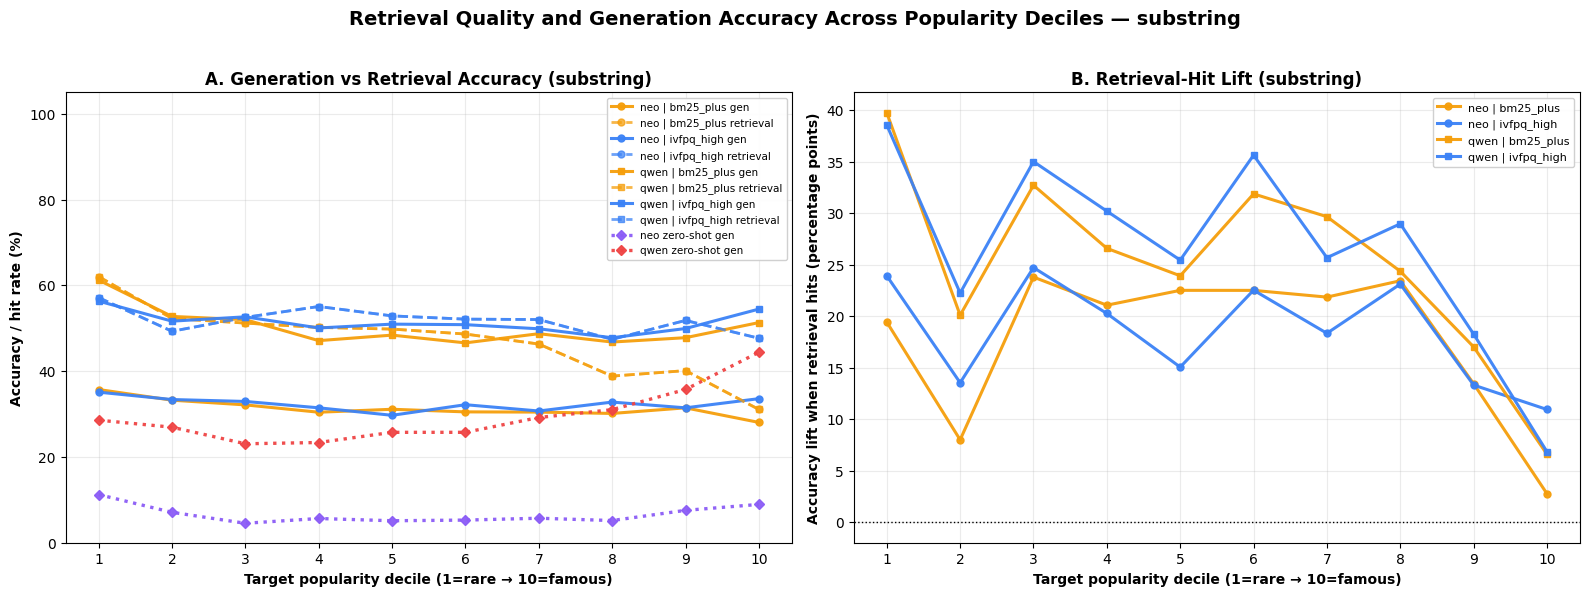

✓ Saved → generation_retrieval_accuracy_and_lift_by_decile_substring.png


In [4]:
def build_evaluator_summary(evaluator):
    eval_df = filter_generation_results(evaluator=evaluator).copy()
    eval_df['decile'] = pd.to_numeric(eval_df[dcol], errors='coerce').astype('Int64')
    eval_df = eval_df.dropna(subset=['decile', 'generation_correct'])
    eval_df['decile_label'] = eval_df['decile'].astype(int) + 1
    eval_summary = (
        eval_df.groupby(['llm', 'backend', 'ctx_label', 'decile_label'])
        .agg(
            generation_accuracy=('generation_correct', 'mean'),
            retrieval_hit_rate=('retrieval_hit', 'mean'),
            n=('generation_correct', 'count'),
            retrieval_n=('retrieval_hit', 'count'),
        )
        .reset_index()
    )
    eval_summary['generation_accuracy_ci95'] = 1.96 * np.sqrt(
        eval_summary['generation_accuracy'] * (1.0 - eval_summary['generation_accuracy']) / eval_summary['n']
    )
    eval_summary['retrieval_hit_rate_ci95'] = 1.96 * np.sqrt(
        eval_summary['retrieval_hit_rate'] * (1.0 - eval_summary['retrieval_hit_rate']) / eval_summary['retrieval_n']
    )
    eval_hit_miss = (
        eval_df[eval_df['retrieval_hit'].notna()]
        .groupby(['llm', 'backend', 'ctx_label', 'decile_label', 'retrieval_hit'])
        .agg(accuracy=('generation_correct', 'mean'), n=('generation_correct', 'count'))
        .reset_index()
    )
    eval_lift = eval_hit_miss.pivot_table(
        index=['llm', 'backend', 'ctx_label', 'decile_label'],
        columns='retrieval_hit', values='accuracy',
    ).reset_index().rename(columns={0.0: 'acc_when_miss', 1.0: 'acc_when_hit'})
    eval_counts = eval_hit_miss.pivot_table(
        index=['llm', 'backend', 'ctx_label', 'decile_label'],
        columns='retrieval_hit', values='n',
    ).reset_index().rename(columns={0.0: 'n_when_miss', 1.0: 'n_when_hit'})
    eval_lift = eval_lift.merge(eval_counts, on=['llm', 'backend', 'ctx_label', 'decile_label'], how='left')
    eval_lift['hit_lift'] = eval_lift.get('acc_when_hit', np.nan) - eval_lift.get('acc_when_miss', np.nan)
    eval_lift['hit_lift_ci95'] = 1.96 * np.sqrt(
        eval_lift['acc_when_hit'] * (1.0 - eval_lift['acc_when_hit']) / eval_lift['n_when_hit']
        + eval_lift['acc_when_miss'] * (1.0 - eval_lift['acc_when_miss']) / eval_lift['n_when_miss']
    )
    return eval_summary.merge(
        eval_lift[['llm', 'backend', 'ctx_label', 'decile_label', 'hit_lift', 'hit_lift_ci95']],
        on=['llm', 'backend', 'ctx_label', 'decile_label'], how='left',
    )

def save_qwen_evaluator_figures(evaluator):
    evaluator_summary = build_evaluator_summary(evaluator)
    qwen = evaluator_summary[evaluator_summary['llm'] == 'qwen'].copy()
    if qwen.empty:
        print(f'No Qwen rows for evaluator={evaluator}')
        return
    labels = {'bm25_plus': 'BM25', 'ivfpq_high': 'FAISS high'}
    retrieved = qwen[qwen['backend'] != 'zero_shot']
    zero = qwen[qwen['backend'] == 'zero_shot'].sort_values('decile_label')

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for backend, sub in retrieved.groupby('backend'):
        sub = sub.sort_values('decile_label')
        label = labels.get(backend, backend)
        color = backend_color(backend)
        ax.errorbar(sub['decile_label'], sub['generation_accuracy'] * 100.0,
                    yerr=sub['generation_accuracy_ci95'] * 100.0, capsize=3,
                    color=color, marker='o', linewidth=2.4, label=f'{label}: generation')
        ax.errorbar(sub['decile_label'], sub['retrieval_hit_rate'] * 100.0,
                    yerr=sub['retrieval_hit_rate_ci95'] * 100.0, capsize=3,
                    color=color, marker='o', linestyle='--', linewidth=2.0,
                    label=f'{label}: retrieval hit')
    if not zero.empty:
        ax.errorbar(zero['decile_label'], zero['generation_accuracy'] * 100.0,
                    yerr=zero['generation_accuracy_ci95'] * 100.0, capsize=3,
                    color='black', marker='D', linestyle=':', linewidth=2.4,
                    label='Zero-shot: generation')
    ax.set(title=f'Qwen: Generation and Retrieval Accuracy ({evaluator})',
           xlabel='Target popularity decile (1=rare → 10=famous)',
           ylabel='Accuracy / retrieval hit rate (%)', ylim=(0, 105))
    ax.set_xticks(range(1, 11)); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='best')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'qwen_generation_retrieval_accuracy_by_decile_{evaluator}.png', dpi=180, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for backend, sub in retrieved.groupby('backend'):
        sub = sub.sort_values('decile_label')
        ax.errorbar(sub['decile_label'], sub['hit_lift'] * 100.0,
                    yerr=sub['hit_lift_ci95'] * 100.0, capsize=3,
                    color=backend_color(backend), marker='o', linewidth=2.4,
                    label=labels.get(backend, backend))
    ax.axhline(0, color='black', linewidth=1, linestyle=':')
    ax.set(title=f'Qwen: Conditional Hit--Miss Difference ({evaluator})',
           xlabel='Target popularity decile (1=rare → 10=famous)',
           ylabel='Hit--miss accuracy difference (percentage points)')
    ax.set_xticks(range(1, 11)); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='best')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'qwen_retrieval_hit_lift_by_decile_{evaluator}.png', dpi=180, bbox_inches='tight')
    plt.show()

binary_evaluators = [ev for ev in AVAILABLE_EVALUATORS if ev.startswith('binary')]
if not binary_evaluators:
    print('No binary evaluator results loaded yet.')
else:
    for binary_evaluator in binary_evaluators:
        save_qwen_evaluator_figures(binary_evaluator)

## Retrieval Hit Rate vs Generation Accuracy

One graph for the central question: do deciles with better retrieval also produce better generated answers? Each point is a popularity decile. Lines connect deciles for the same LLM/backend run. Zero-shot has no retrieval hit rate, so it is shown as a horizontal baseline.

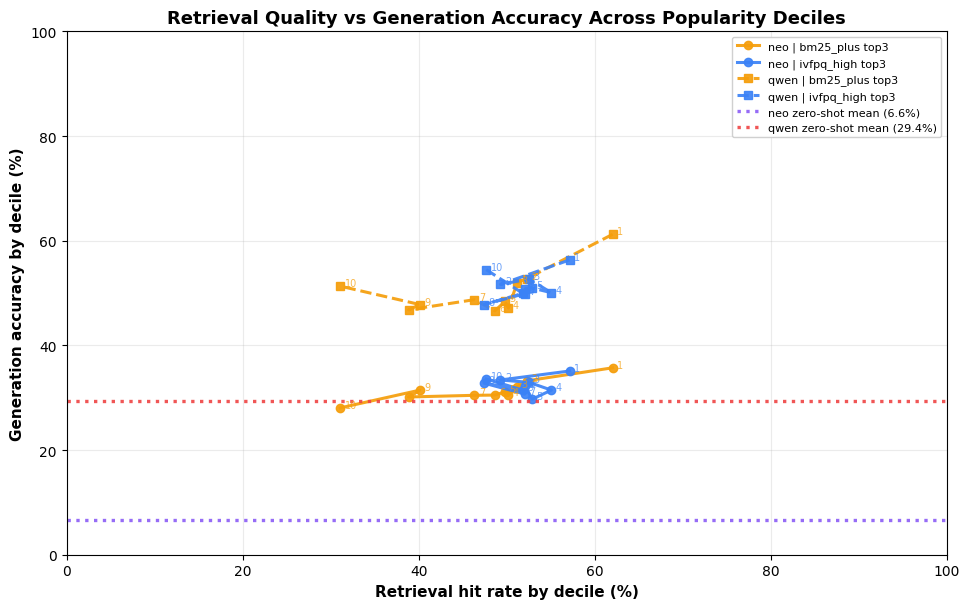

✓ Saved → retrieval_vs_generation_accuracy_with_zero_shot.png


In [5]:
fig, ax = plt.subplots(figsize=(9.8, 6.2))

retrieval_summary = summary[summary['retrieval_hit_rate'].notna()].copy()
for (llm, backend, ctx), sub in retrieval_summary.groupby(['llm', 'backend', 'ctx_label']):
    sub = sub.sort_values('decile_label')
    color = backend_color(backend)
    marker = 'o' if llm == 'neo' else 's'
    linestyle = '-' if llm == 'neo' else '--'
    label = f'{llm} | {backend} {ctx}'
    ax.plot(
        sub['retrieval_hit_rate'] * 100.0,
        sub['generation_accuracy'] * 100.0,
        marker=marker, linestyle=linestyle, linewidth=2.2, markersize=6,
        color=color, alpha=0.92, label=label,
    )
    for _, row in sub.iterrows():
        ax.text(
            row['retrieval_hit_rate'] * 100.0 + 0.5,
            row['generation_accuracy'] * 100.0,
            str(int(row['decile_label'])),
            fontsize=7, color=color, alpha=0.75,
        )

zero = summary[summary['backend'] == 'zero_shot'].copy()
for llm, sub in zero.groupby('llm'):
    baseline = float(sub['generation_accuracy'].mean()) * 100.0
    ax.axhline(
        baseline,
        color=llm_color(llm), linestyle=':', linewidth=2.4, alpha=0.90,
        label=f'{llm} zero-shot mean ({baseline:.1f}%)',
    )

ax.set_xlabel('Retrieval hit rate by decile (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Generation accuracy by decile (%)', fontsize=11, fontweight='bold')
ax.set_title('Retrieval Quality vs Generation Accuracy Across Popularity Deciles',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.25)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(fontsize=8, framealpha=0.92, loc='best')
plt.tight_layout()
out = IMAGES_DIR / 'retrieval_vs_generation_accuracy_with_zero_shot.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## Correlation Summary

A small table for the same question: across popularity deciles, do runs with higher retrieval hit rates also have higher generated-answer accuracy?

In [6]:
corr_df = retrieval_generation_correlation(evaluator=EVALUATOR, mode=MODE)
display(corr_df.round(4))

,llm,backend,ctx_label,pearson_r,spearman_r,n_deciles
0,neo,bm25_plus,top3,0.8602,0.8061,10
1,neo,ivfpq_high,top3,-0.0171,-0.1152,10
2,qwen,bm25_plus,top3,0.5644,0.5515,10
3,qwen,ivfpq_high,top3,0.3590,0.3576,10


## Finding: Generation Compresses the Retrieval Gap

![Qwen generation and retrieval accuracy by decile](images/qwen_generation_retrieval_accuracy_by_decile.png)

Retrieval quality is most strongly associated with generation accuracy for rare and mid-popularity entities. For Qwen, BM25 retrieval accuracy drops strongly across popularity deciles, and generation accuracy follows the same broad trend. FAISS high is more stable, while zero-shot accuracy rises toward the most popular deciles. This pattern is consistent with retrieval being most valuable where parametric knowledge is weakest.

![Qwen conditional hit--miss accuracy difference by decile](images/qwen_retrieval_hit_lift_by_decile.png)

The conditional hit--miss comparison shows that answer accuracy is higher when the retrieved context contains the gold article, especially for lower and middle popularity deciles. This is an association rather than a causal estimate: questions that retrieve successfully may also be easier for other reasons. In the highest deciles, the difference shrinks, consistent with Qwen answering more questions from parametric knowledge even when exact retrieval fails.

The final answer stage therefore reduces visible backend differences. Retrieval-stage gaps are large, but high-popularity retrieval failures are more often accompanied by successful zero-shot answers. Neo shows the same qualitative pattern, so the paper figure can focus on Qwen for readability.

**Conclusion.** Generation does not remove popularity effects; it changes where they appear. Rare entities remain more retrieval-dependent, while zero-shot knowledge catches up for popular entities. This produces smaller differences in final generation quality than in retrieval accuracy itself.